# Data Loading

In [1]:
import pandas as pd

df = pd.read_csv("Final_Data.csv")

df


,Age,Blood Pressure,Glucose Level,Cholesterol,Exercise Level,Sleep Hours,Family history of disease,Diet quality,Heart rate,Waist circumference,Target Disease Risk
0,56,99,76,294,2,8.9,0,1,69,108.6,0
1,69,91,82,234,1,7.9,1,0,108,64.1,0
2,46,155,189,286,0,9.0,1,1,72,65.7,2
3,32,149,135,293,0,9.7,1,1,61,80.5,2
4,60,177,73,272,1,5.6,1,1,67,67.1,2
...,...,...,...,...,...,...,...,...,...,...,...
2000,20,163,188,202,2,4.3,0,1,101,110.7,2
2001,54,140,127,229,0,6.1,1,1,104,77.2,2
2002,60,156,132,165,1,4.5,0,1,107,74.5,1
2003,57,165,169,253,2,6.4,0,1,108,100.9,2


# Separate features and target

In [2]:
X = df.drop('Target Disease Risk',axis=1)
y = df['Target Disease Risk']

# Train-test split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Train Random Forest model

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully")


Random Forest trained successfully


# Make predictions

In [5]:
y_pred = rf_model.predict(X_test)


# Model Evaluation

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    log_loss
)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

Accuracy: 0.8229426433915212
Precision: 0.8028961714862326
Recall: 0.8229426433915212
F1 Score: 0.8017045534961157


# Confusion matrix

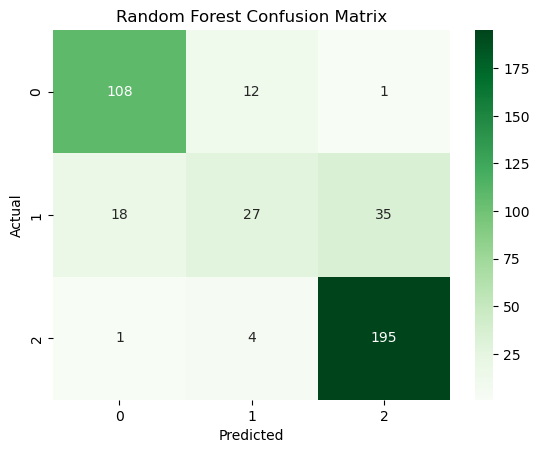

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


# ROC AUC and Log Loss

In [9]:
y_prob_rf = rf_model.predict_proba(X_test)

print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf, multi_class="ovr"))
print("Log Loss:", log_loss(y_test, y_prob_rf))


ROC AUC Score: 0.929109551946213
Log Loss: 0.4757738512537232


# ROC curve Plot

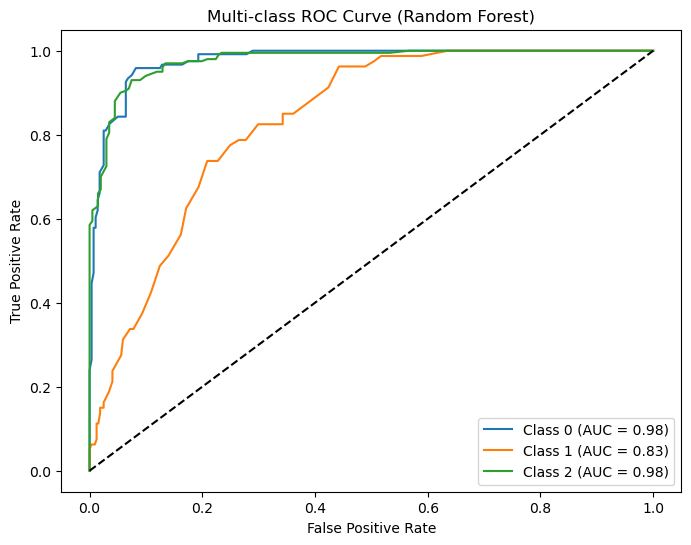

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)


y_prob = rf_model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

# diagonal reference line
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve (Random Forest)")
plt.legend()
plt.show()



# Saving Model

In [12]:
import pickle

with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
print('Model Saved')

Model Saved
